In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Signal Processing Functions
def magnitude(signal, samples_number):
    return np.sqrt(np.dot(signal, signal) / samples_number)


def GM_Bases(s1, s2, samples_number):
    # calculate phi_1 as normalized of first signal
    phi_1 = s1 / np.sqrt(magnitude(s1, samples_number))

    # calculate phi_2 as orthogonal to phi_1
    phi_2 = s2 - phi_1 * np.dot(phi_1, s2) / samples_number
    phi_2_norm = np.sqrt(magnitude(phi_2, samples_number))

    # special case: s1 and s2 have one basis function
    if phi_2_norm == 0:
        phi_2 = np.zeros_like(phi_2)
    else:
        phi_2 /= phi_2_norm

    return phi_1, phi_2


def signal_space(s, phi1, phi2, samples_number):
    v1 = np.dot(s, phi1) / samples_number
    v2 = np.dot(s, phi2) / samples_number
    return {"v1": v1, "v2": v2}


def add_noise(s, E_No, samples_number):
    E = magnitude(s, samples_number)
    E_No = 10 ** (E_No / 10)
    sigma_squared = E / E_No
    noise = np.random.normal(0, np.sqrt(sigma_squared), samples_number)
    return s + noise


# Plotting Functions
def plot_signal(signal, t, title):
    plt.figure()
    plt.plot(t, signal)
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel("amplitude")
    plt.grid()
    plt.show()


def plot_signal_space(signals, titles, colors):
    plt.figure(figsize=(10, 7))

    for i in range(len(signals)):
        plt.plot(
            signals[i]["v1"], signals[i]["v2"], f"{colors[i]}o", label=f"{titles[i]}"
        )
        plt.plot([0, signals[i]["v1"]], [0, signals[i]["v2"]], color=colors[i])

    plt.title("Signal Space")
    plt.xlabel("phi_1")
    plt.ylabel("phi_2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_signal_space_result(r1_org, r2_org, noisy_r1_points, noisy_r2_points, SNR):
    plt.figure()
    plt.title(f"Signal Space with SNR = {SNR} dB")

    r1_points = np.array([[p["v1"], p["v2"]] for p in noisy_r1_points])
    r2_points = np.array([[p["v1"], p["v2"]] for p in noisy_r2_points])

    r1_vis, r1_v2s = r1_points.T
    r2_vis, r2_v2s = r2_points.T

    plt.scatter(r1_vis, r1_v2s, label="r1", color="cyan", marker=".", alpha=0.3, s=50)
    plt.scatter(r2_vis, r2_v2s, label="r2", color="orange", marker=".", alpha=0.3, s=50)
    plt.scatter(r1_org["v1"], r1_org["v2"], label="s1", color="blue", s=50)
    plt.scatter(r2_org["v1"], r2_org["v2"], label="s2", color="red", s=50)

    plt.legend()
    plt.grid(True)
    plt.xlabel("phi_1 projection")
    plt.ylabel("phi_2 projection")
    plt.show()

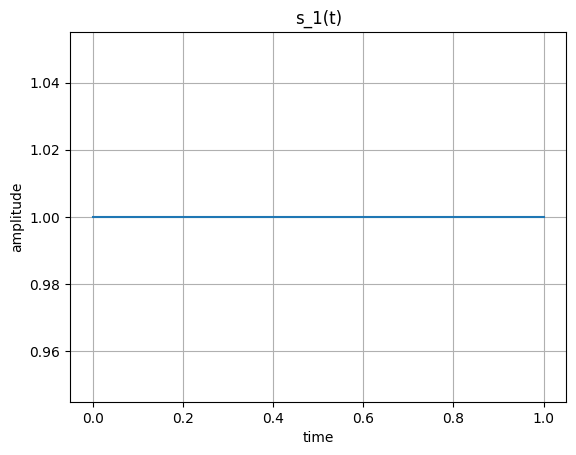

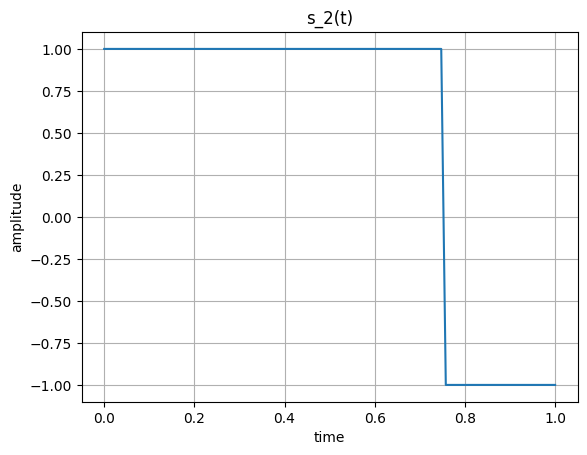

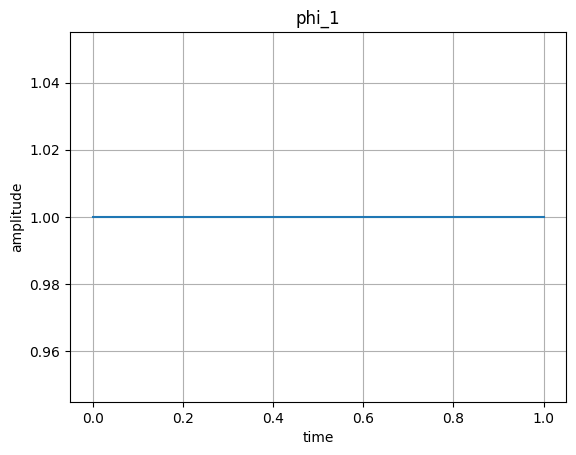

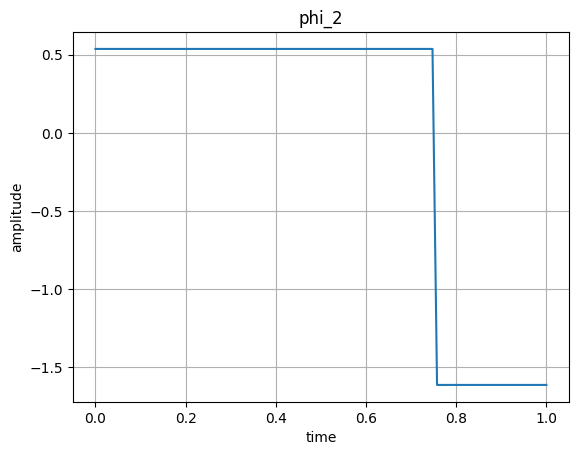

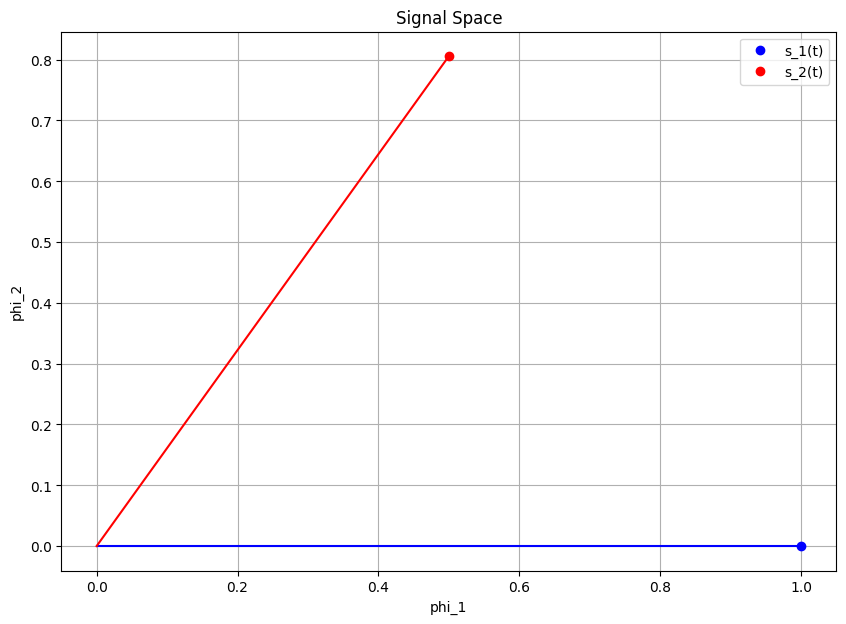

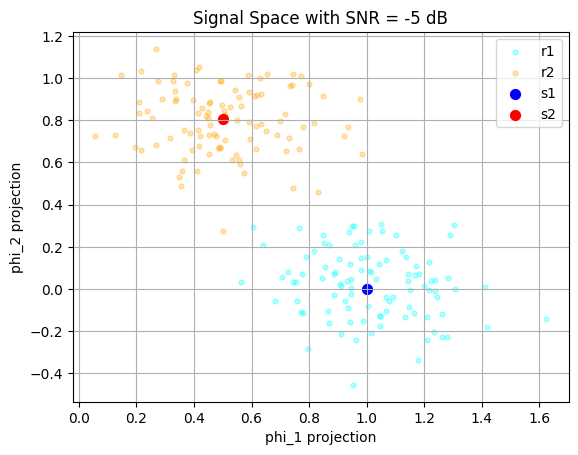

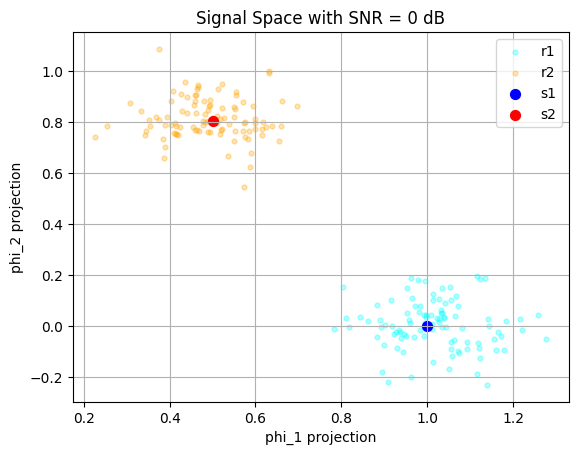

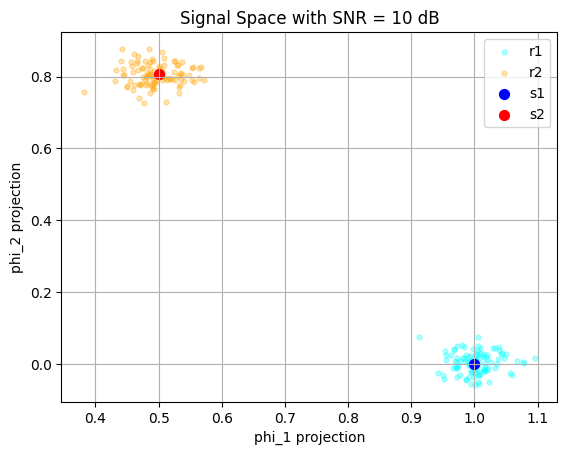

In [12]:
# Experiment
samples_number = 100
t = np.linspace(0, 1, samples_number)

# Generate signals and plot them
s1 = np.ones(samples_number)
s2 = np.ones(samples_number)
s2[75:] = -1

plot_signal(s1, t, "s_1(t)")
plot_signal(s2, t, "s_2(t)")

# Calculate and plot basis functions
phi_1, phi_2 = GM_Bases(s1, s2, samples_number)
plot_signal(phi_1, t, "phi_1")
plot_signal(phi_2, t, "phi_2")

# Plot signal space representation
signal_1 = signal_space(s1, phi_1, phi_2, samples_number)
signal_2 = signal_space(s2, phi_1, phi_2, samples_number)
plot_signal_space([signal_1, signal_2], ["s_1(t)", "s_2(t)"], ["b", "r"])

# Add noise and plot results for different SNR values
SNR_values = [-5, 0, 10]
for SNR in SNR_values:
    r1 = signal_space(s1, phi_1, phi_2, samples_number)
    r2 = signal_space(s2, phi_1, phi_2, samples_number)

    noisy_r1_points = []
    noisy_r2_points = []

    for _ in range(samples_number):
        r1_noisy = add_noise(s1, SNR, samples_number)
        r2_noisy = add_noise(s2, SNR, samples_number)

        r1_noisy_proj = signal_space(r1_noisy, phi_1, phi_2, samples_number)
        r2_noisy_proj = signal_space(r2_noisy, phi_1, phi_2, samples_number)

        noisy_r1_points.append(r1_noisy_proj)
        noisy_r2_points.append(r2_noisy_proj)

    plot_signal_space_result(r1, r2, noisy_r1_points, noisy_r2_points, SNR)